**Objective: Predict the percentage change in Zillow Home Value Index (ZHVI) for each region over the following 12 months.**


*   Target Appreciation 12M = ((Future Home Value{t+12} - Home Value{t}) / Home Value{t}) * 100

*   This is a supervised regression problem because the target is a continuous percentage value.

*   Primary metric: Mean Absolute Error (MAE), measured in percentage points.
Secondary metrics: Root Mean Squared Error (RMSE) and R².
*   Business constraints: The model must avoid future-data leakage, remain explainable, and be practical to deploy as a historical forecasting demonstration.

In [1]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


# !pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
# from google.colab import files
# uploaded = files.upload()

# Assuming only one file is uploaded, get its name
# file_name = list(uploaded.keys())[0]

df = pd.read_csv('City_Zhvi_SingleFamilyResidence.csv')
display(df.head())

,Unnamed: 0,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,1996-01-31,...,2019-06-30,2019-07-31,2019-08-31,2019-09-30,2019-10-31,2019-11-30,2019-12-31,2020-01-31,2020-02-29,2020-03-31
0,0,6181,0,New York,City,NY,NY,New York-Newark-Jersey City,Queens County,208545.0,...,672433.0,671924.0,671423.0,670719.0,669974.0,669118.0,668736.0,668740.0,668581.0,668030.0
1,1,12447,1,Los Angeles,City,CA,CA,Los Angeles-Long Beach-Anaheim,Los Angeles County,192855.0,...,745290.0,746729.0,748924.0,751756.0,755716.0,759279.0,764877.0,770853.0,779717.0,788751.0
2,2,39051,2,Houston,City,TX,TX,Houston-The Woodlands-Sugar Land,Harris County,95018.0,...,189803.0,190437.0,191052.0,191483.0,192124.0,192620.0,193202.0,193427.0,193991.0,194986.0
3,3,17426,3,Chicago,City,IL,IL,Chicago-Naperville-Elgin,Cook County,126867.0,...,226322.0,226635.0,226796.0,226645.0,226505.0,226430.0,226454.0,226727.0,227077.0,227605.0
4,4,6915,4,San Antonio,City,TX,TX,San Antonio-New Braunfels,Bexar County,94406.0,...,183622.0,184246.0,184831.0,185752.0,186401.0,187159.0,187339.0,187886.0,188055.0,188650.0


In [4]:
df.shape

(27326, 300)

*  This dataset contains Zillow Home Value Index records across US geographic regions. The raw dataset is in wide format, where each date is stored as a separate column.
*   The initial inspection checks dataset dimensions, data types, missing values, and available geographic identifiers.




In [5]:
df.head()

,Unnamed: 0,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,1996-01-31,...,2019-06-30,2019-07-31,2019-08-31,2019-09-30,2019-10-31,2019-11-30,2019-12-31,2020-01-31,2020-02-29,2020-03-31
0,0,6181,0,New York,City,NY,NY,New York-Newark-Jersey City,Queens County,208545.0,...,672433.0,671924.0,671423.0,670719.0,669974.0,669118.0,668736.0,668740.0,668581.0,668030.0
1,1,12447,1,Los Angeles,City,CA,CA,Los Angeles-Long Beach-Anaheim,Los Angeles County,192855.0,...,745290.0,746729.0,748924.0,751756.0,755716.0,759279.0,764877.0,770853.0,779717.0,788751.0
2,2,39051,2,Houston,City,TX,TX,Houston-The Woodlands-Sugar Land,Harris County,95018.0,...,189803.0,190437.0,191052.0,191483.0,192124.0,192620.0,193202.0,193427.0,193991.0,194986.0
3,3,17426,3,Chicago,City,IL,IL,Chicago-Naperville-Elgin,Cook County,126867.0,...,226322.0,226635.0,226796.0,226645.0,226505.0,226430.0,226454.0,226727.0,227077.0,227605.0
4,4,6915,4,San Antonio,City,TX,TX,San Antonio-New Braunfels,Bexar County,94406.0,...,183622.0,184246.0,184831.0,185752.0,186401.0,187159.0,187339.0,187886.0,188055.0,188650.0


In [6]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [7]:
id_cols = [
    "RegionID",
    "SizeRank",
    "RegionName",
    "RegionType",
    "StateName",
    "State",
    "Metro",
    "CountyName"
]

date_cols = [col for col in df.columns if col not in id_cols]
date_cols

['1996-01-31',
 '1996-02-29',
 '1996-03-31',
 '1996-04-30',
 '1996-05-31',
 '1996-06-30',
 '1996-07-31',
 '1996-08-31',
 '1996-09-30',
 '1996-10-31',
 '1996-11-30',
 '1996-12-31',
 '1997-01-31',
 '1997-02-28',
 '1997-03-31',
 '1997-04-30',
 '1997-05-31',
 '1997-06-30',
 '1997-07-31',
 '1997-08-31',
 '1997-09-30',
 '1997-10-31',
 '1997-11-30',
 '1997-12-31',
 '1998-01-31',
 '1998-02-28',
 '1998-03-31',
 '1998-04-30',
 '1998-05-31',
 '1998-06-30',
 '1998-07-31',
 '1998-08-31',
 '1998-09-30',
 '1998-10-31',
 '1998-11-30',
 '1998-12-31',
 '1999-01-31',
 '1999-02-28',
 '1999-03-31',
 '1999-04-30',
 '1999-05-31',
 '1999-06-30',
 '1999-07-31',
 '1999-08-31',
 '1999-09-30',
 '1999-10-31',
 '1999-11-30',
 '1999-12-31',
 '2000-01-31',
 '2000-02-29',
 '2000-03-31',
 '2000-04-30',
 '2000-05-31',
 '2000-06-30',
 '2000-07-31',
 '2000-08-31',
 '2000-09-30',
 '2000-10-31',
 '2000-11-30',
 '2000-12-31',
 '2001-01-31',
 '2001-02-28',
 '2001-03-31',
 '2001-04-30',
 '2001-05-31',
 '2001-06-30',
 '2001-07-

In [8]:
df_long = df.melt(
    id_vars=id_cols,
    value_vars=date_cols,
    var_name="Date",
    value_name="HomeValue"
)

df_long["Date"] = pd.to_datetime(df_long["Date"])

df_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,Date,HomeValue
0,6181,0,New York,City,NY,NY,New York-Newark-Jersey City,Queens County,1996-01-31,208545.0
1,12447,1,Los Angeles,City,CA,CA,Los Angeles-Long Beach-Anaheim,Los Angeles County,1996-01-31,192855.0
2,39051,2,Houston,City,TX,TX,Houston-The Woodlands-Sugar Land,Harris County,1996-01-31,95018.0
3,17426,3,Chicago,City,IL,IL,Chicago-Naperville-Elgin,Cook County,1996-01-31,126867.0
4,6915,4,San Antonio,City,TX,TX,San Antonio-New Braunfels,Bexar County,1996-01-31,94406.0


In [9]:
num_regions = df_long[["RegionName", "State", "CountyName"]].drop_duplicates().shape[0]
num_dates = df_long["Date"].nunique()

print(f"Unique Regions: {num_regions}")
print(f"Unique Dates: {num_dates}")
print(f"Multiplied Total: {num_regions * num_dates:,} rows")

Unique Regions: 27326
Unique Dates: 291
Multiplied Total: 7,951,866 rows


In [10]:
df_long = df_long.dropna(subset=["HomeValue"])
df_long.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 5904770 entries, 0 to 7951865
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   RegionID    5904770 non-null  int64         
 1   SizeRank    5904770 non-null  int64         
 2   RegionName  5904770 non-null  str           
 3   RegionType  5904770 non-null  str           
 4   StateName   5904770 non-null  str           
 5   State       5904770 non-null  str           
 6   Metro       4679113 non-null  str           
 7   CountyName  5904770 non-null  str           
 8   Date        5904770 non-null  datetime64[us]
 9   HomeValue   5904770 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 495.5 MB


In [11]:
df_long["year"] = df_long["Date"].dt.year
df_long["month"] = df_long["Date"].dt.month

# df_long.head()

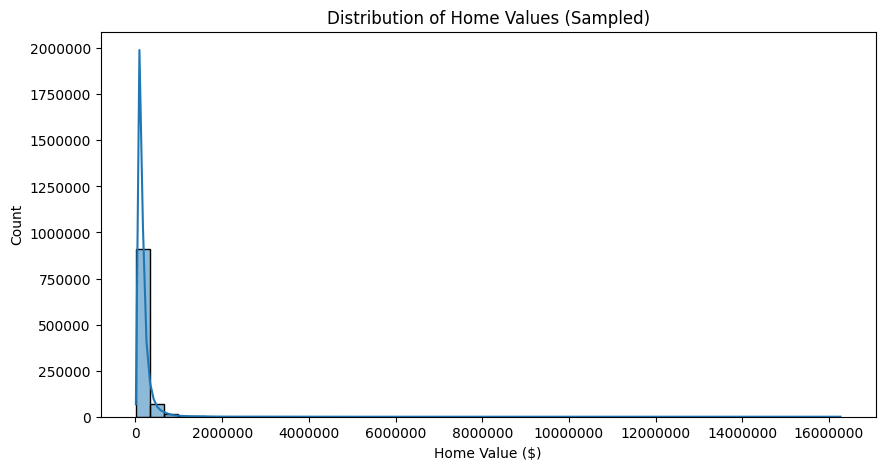

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df_long['HomeValue'].sample(1000000, random_state=42), bins=50, kde=True)
plt.title('Distribution of Home Values (Sampled)')
plt.xlabel('Home Value ($)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='both') # Prevents scientific notation
plt.show()

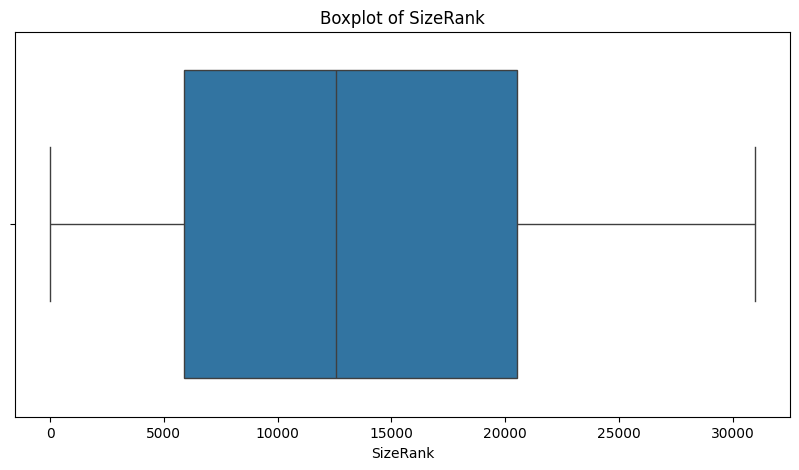

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_long['SizeRank'].sample(100000, random_state=42))
plt.title('Boxplot of SizeRank')
plt.show()

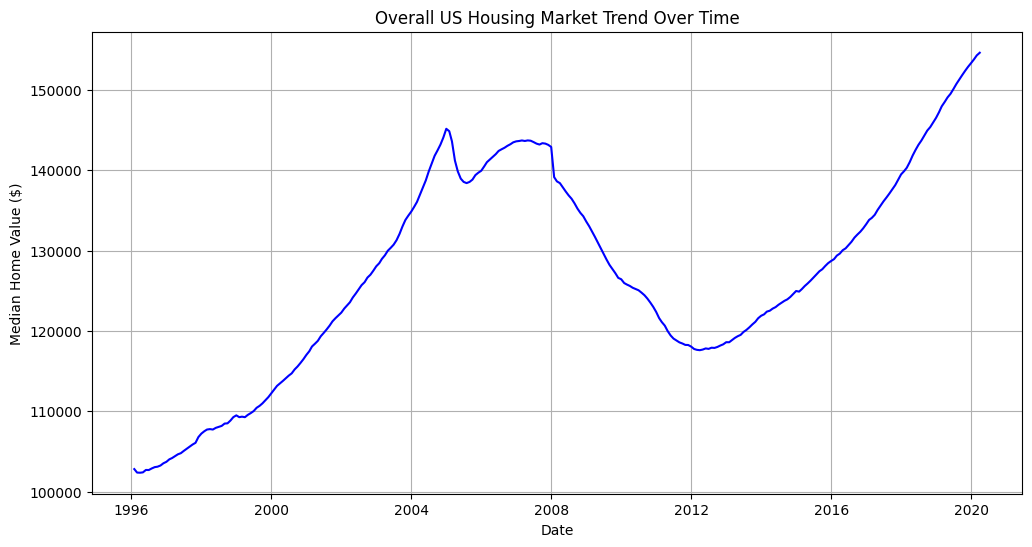

In [14]:
# Group by Date and find the median housing value across the country
macro_trend = df_long.groupby('Date')['HomeValue'].median().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(macro_trend['Date'], macro_trend['HomeValue'], label='US Median ZHVI', color='blue')
plt.title('Overall US Housing Market Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Median Home Value ($)')
plt.grid(True)
plt.show()

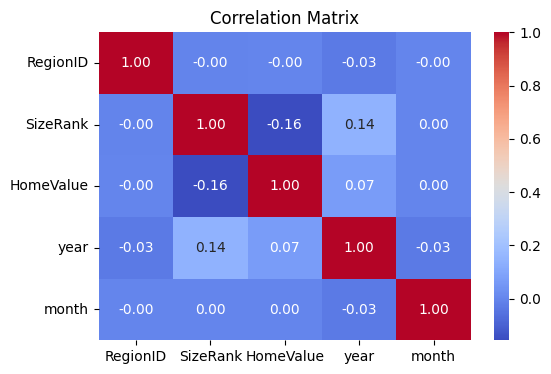

In [15]:
plt.figure(figsize=(6, 4))
numeric_cols = df_long.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [16]:
df_long['Metro'] = df_long['Metro'].fillna('Rural')
df_long[df_long['Metro'] == "Rural"].count()

RegionID      1225657
SizeRank      1225657
RegionName    1225657
RegionType    1225657
StateName     1225657
State         1225657
Metro         1225657
CountyName    1225657
Date          1225657
HomeValue     1225657
year          1225657
month         1225657
dtype: int64

In [17]:
# Work on a separate modelling dataframe
df_work = df_long.copy()

 # Keep only valid positive ZHVI values
df_work = df_work[df_work["HomeValue"] > 0].copy()

 # Sort before any time-series work
df_work = df_work.sort_values(["RegionID", "Date"]).reset_index(drop=True)
df_work.head()



,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,Date,HomeValue,year,month
0,3299,27247,Abbott Township,City,PA,PA,Rural,Potter County,2005-05-31,57432.0,2005,5
1,3299,27247,Abbott Township,City,PA,PA,Rural,Potter County,2005-06-30,57917.0,2005,6
2,3299,27247,Abbott Township,City,PA,PA,Rural,Potter County,2005-07-31,58643.0,2005,7
3,3299,27247,Abbott Township,City,PA,PA,Rural,Potter County,2005-08-31,60139.0,2005,8
4,3299,27247,Abbott Township,City,PA,PA,Rural,Potter County,2005-09-30,61773.0,2005,9


In [18]:
# The date whose HomeValue we want to predict indirectly
df_work["FutureDate_12M"] = df_work["Date"] + pd.offsets.MonthEnd(12)

#  Create a lookup table: RegionID + future date -> future HomeValue
future_lookup = (
      df_work[["RegionID", "Date", "HomeValue"]]
       .rename(columns={
         "Date": "FutureDate_12M",
        "HomeValue": "Future_HomeValue_12M"
    })
)

In [19]:
# Match each current observation to the exact same region 12 calendar months later
df_model = df_work.merge(
    future_lookup,
    on=["RegionID", "FutureDate_12M"],
    how="left",
    validate="many_to_one"
)


In [20]:
# Compute percentage appreciation
df_model["Target_Appreciation_12M"] = (
    (df_model["Future_HomeValue_12M"] - df_model["HomeValue"])
    / df_model["HomeValue"]
) * 100

# Keep only rows with a known future value
df_model = df_model.dropna(
    subset=["Future_HomeValue_12M", "Target_Appreciation_12M"]
).copy()

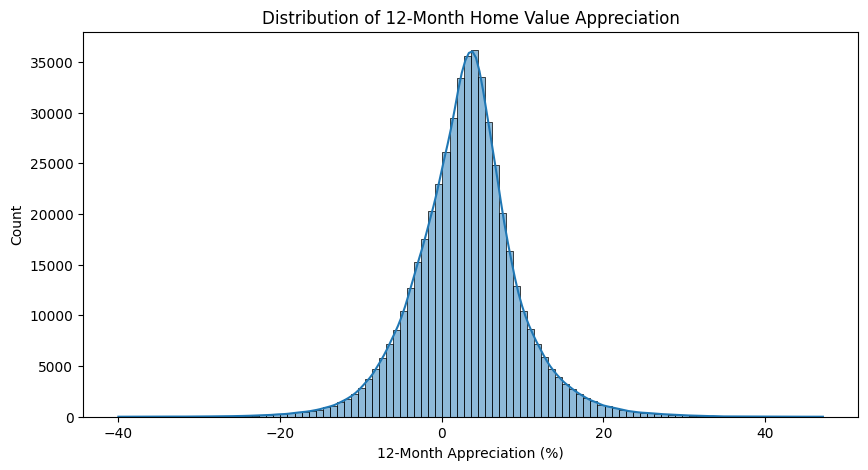

0.001   -23.609446
0.005   -16.799931
0.010   -13.797605
0.990    20.857698
0.995    24.012745
0.999    30.316035
Name: Target_Appreciation_12M, dtype: float64


In [21]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_model["Target_Appreciation_12M"]
    .sample(min(500000, len(df_model)), random_state=42),
    bins=100,
    kde=True
)

plt.title("Distribution of 12-Month Home Value Appreciation")
plt.xlabel("12-Month Appreciation (%)")
plt.ylabel("Count")
plt.show()

print(
    df_model["Target_Appreciation_12M"].quantile(
        [0.001, 0.005, 0.01, 0.99, 0.995, 0.999]
    )
)

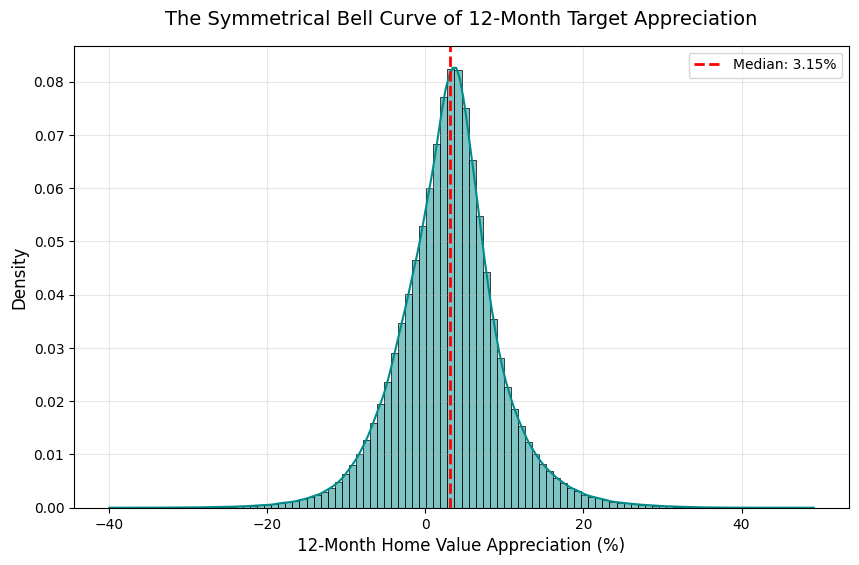

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample 100k points for quick plotting
sampled_target = df_model["Target_Appreciation_12M"].sample(1000000, random_state=42)

plt.figure(figsize=(10, 6))

# Plot the distribution histogram with a smooth Kernel Density Estimate (KDE) line
sns.histplot(sampled_target, bins=100, kde=True, color="darkcyan", stat="density")

# Add a vertical line exactly at the median to see the center point
plt.axvline(df_model["Target_Appreciation_12M"].median(), color="red", linestyle="--", linewidth=2, label=f"Median: {df_model['Target_Appreciation_12M'].median():.2f}%")

plt.title("The Symmetrical Bell Curve of 12-Month Target Appreciation", fontsize=14, pad=15)
plt.xlabel("12-Month Home Value Appreciation (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
monthly_check = df_work[["RegionID", "Date"]].copy()

monthly_check["MonthNumber"] = (
    monthly_check["Date"].dt.year * 12
    + monthly_check["Date"].dt.month
)

monthly_check = monthly_check.sort_values(["RegionID", "Date"])
monthly_check["MonthGap"] = (
    monthly_check.groupby("RegionID")["MonthNumber"].diff()
)

internal_gaps = (monthly_check["MonthGap"] > 1).sum()
print("Internal monthly gaps found:", internal_gaps)

Internal monthly gaps found: 0


1.   Train:       1996-01 to 2014-12
2.   Gap:         2015
3.   Validation:  2016
4.   Gap:         2017
5.   Test:        2018-01 to 2019-03

In [23]:
# Create historical lag and trend features
df_model = df_model.sort_values(["RegionID", "Date"]).copy()

grouped_homevalue = df_model.groupby("RegionID")["HomeValue"]

# Historical ZHVI levels
df_model["HomeValue_Lag_1M"] = grouped_homevalue.shift(1)
df_model["HomeValue_Lag_3M"] = grouped_homevalue.shift(3)
df_model["HomeValue_Lag_6M"] = grouped_homevalue.shift(6)
df_model["HomeValue_Lag_12M"] = grouped_homevalue.shift(12)

# Historical appreciation / momentum
df_model["Growth_3M_pct"] = (
    (df_model["HomeValue"] - df_model["HomeValue_Lag_3M"])
    / df_model["HomeValue_Lag_3M"]
) * 100

df_model["Growth_6M_pct"] = (
    (df_model["HomeValue"] - df_model["HomeValue_Lag_6M"])
    / df_model["HomeValue_Lag_6M"]
) * 100

df_model["Growth_12M_pct"] = (
    (df_model["HomeValue"] - df_model["HomeValue_Lag_12M"])
    / df_model["HomeValue_Lag_12M"]
) * 100

# Rolling features: shift(1) ensures the current observation is not included
df_model["RollingMean_3M"] = (
    grouped_homevalue
    .transform(lambda s: s.shift(1).rolling(window=3, min_periods=3).mean())
)

df_model["RollingStd_6M"] = (
    grouped_homevalue
    .transform(lambda s: s.shift(1).rolling(window=6, min_periods=6).std())
)


**Feature Engineered Dataset**

In [24]:
# Seasonal features: month is cyclical, not truly linear
df_model["Month_Sin"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["Month_Cos"] = np.cos(2 * np.pi * df_model["month"] / 12)

# Remove early rows where historical features do not yet exist
lag_features = [
    "HomeValue_Lag_1M",
    "HomeValue_Lag_3M",
    "HomeValue_Lag_6M",
    "HomeValue_Lag_12M",
    "Growth_3M_pct",
    "Growth_6M_pct",
    "Growth_12M_pct",
    "RollingMean_3M",
    "RollingStd_6M"
]

df_model_features = df_model.dropna(subset=lag_features).copy()

print("Feature-engineered dataset shape:", df_model_features.shape)
print("Remaining date range:")
print(df_model_features["Date"].min(), "to", df_model_features["Date"].max())

Feature-engineered dataset shape: (5248946, 26)
Remaining date range:
1997-01-31 00:00:00 to 2019-03-31 00:00:00


In [25]:
train_mask = df_model_features["Date"] <= "2014-12-31"

val_mask = (
    (df_model_features["Date"] >= "2016-01-31")
    & (df_model_features["Date"] <= "2016-12-31")
)

test_mask = (
    (df_model_features["Date"] >= "2018-01-31")
    & (df_model_features["Date"] <= "2019-03-31")
)

df_train_features = df_model_features.loc[train_mask].copy()
df_val_features = df_model_features.loc[val_mask].copy()
df_test_features = df_model_features.loc[test_mask].copy()

print("Train:", df_train_features.shape)
print("Validation:", df_val_features.shape)
print("Test:", df_test_features.shape)

Train: (3896655, 26)
Validation: (316000, 26)
Test: (406959, 26)


In [26]:
feature_target_cols = [
    "HomeValue",
    "SizeRank",
    "year",
    "month",
    "HomeValue_Lag_1M",
    "HomeValue_Lag_3M",
    "HomeValue_Lag_6M",
    "HomeValue_Lag_12M",
    "Growth_3M_pct",
    "Growth_6M_pct",
    "Growth_12M_pct",
    "RollingMean_3M",
    "RollingStd_6M",
    "Month_Sin",
    "Month_Cos",
    "Target_Appreciation_12M"
]

The naive baseline predicted future 12-month appreciation using the region’s previous 12-month appreciation. It produced an MAE of 3.719 percentage points, RMSE of 5.316 percentage points, and R² of -0.567 on the validation set. The negative R² shows that simple momentum continuation performs worse than predicting the average appreciation rate, meaning prior annual growth alone is not sufficient to forecast future housing appreciation. This justifies training machine learning models using broader historical, geographic, seasonal, and volatility-based features.

In [27]:
y_val = df_val_features["Target_Appreciation_12M"]

# Naive forecasting rule:
# predict that next year's appreciation equals the previous year's appreciation.
naive_pred = df_val_features["Growth_12M_pct"]

naive_mae = mean_absolute_error(y_val, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_val, naive_pred))
naive_r2 = r2_score(y_val, naive_pred)

print(f"Naive baseline MAE:  {naive_mae:.3f} percentage points")
print(f"Naive baseline RMSE: {naive_rmse:.3f} percentage points")
print(f"Naive baseline R²:   {naive_r2:.3f}")

Naive baseline MAE:  3.719 percentage points
Naive baseline RMSE: 5.316 percentage points
Naive baseline R²:   -0.567


In [28]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

X_dummy_train = df_train_features[["Growth_12M_pct"]]  # placeholder feature
y_dummy_train = df_train_features["Target_Appreciation_12M"]

X_dummy_val = df_val_features[["Growth_12M_pct"]]
y_dummy_val = df_val_features["Target_Appreciation_12M"]

dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_dummy_train, y_dummy_train)

dummy_pred = dummy_model.predict(X_dummy_val)

dummy_mae = mean_absolute_error(y_dummy_val, dummy_pred)
dummy_rmse = root_mean_squared_error(y_dummy_val, dummy_pred)
dummy_r2 = r2_score(y_dummy_val, dummy_pred)

print(f"Dummy mean baseline MAE:  {dummy_mae:.3f} percentage points")
print(f"Dummy mean baseline RMSE: {dummy_rmse:.3f} percentage points")
print(f"Dummy mean baseline R²:   {dummy_r2:.3f}")

Dummy mean baseline MAE:  3.717 percentage points
Dummy mean baseline RMSE: 4.855 percentage points
Dummy mean baseline R²:   -0.306


In [29]:
from sklearn.feature_selection import mutual_info_regression

numeric_features_for_mi = [
    "HomeValue",
    "SizeRank",
    "year",
    "month",
    "HomeValue_Lag_1M",
    "HomeValue_Lag_3M",
    "HomeValue_Lag_6M",
    "HomeValue_Lag_12M",
    "Growth_3M_pct",
    "Growth_6M_pct",
    "Growth_12M_pct",
    "RollingMean_3M",
    "RollingStd_6M",
    "Month_Sin",
    "Month_Cos"
]

mi_sample = df_train_features.sample(
    n=min(200000, len(df_train_features)),
    random_state=42
)

mi_scores = mutual_info_regression(
    mi_sample[numeric_features_for_mi],
    mi_sample["Target_Appreciation_12M"],
    random_state=42
)

mi_results = (
    pd.DataFrame({
        "Feature": numeric_features_for_mi,
        "Mutual_Information": mi_scores
    })
    .sort_values("Mutual_Information", ascending=False)
)

display(mi_results.sort_values(by="Mutual_Information",ascending=False))

,Feature,Mutual_Information
2,year,0.295497
9,Growth_6M_pct,0.236391
8,Growth_3M_pct,0.232951
10,Growth_12M_pct,0.212697
12,RollingStd_6M,0.088048
6,HomeValue_Lag_6M,0.032356
0,HomeValue,0.031738
5,HomeValue_Lag_3M,0.030817
7,HomeValue_Lag_12M,0.030742
11,RollingMean_3M,0.030219


In [30]:
numeric_features = [
    "HomeValue",
    "SizeRank",
    "year",
    "Month_Sin",
    "Month_Cos",
    "HomeValue_Lag_1M",
    "HomeValue_Lag_3M",
    "HomeValue_Lag_6M",
    "HomeValue_Lag_12M",
    "Growth_3M_pct",
    "Growth_6M_pct",
    "Growth_12M_pct",
    "RollingMean_3M",
    "RollingStd_6M"
]

categorical_features = [
    "RegionType",
    "State",
    "Metro",
    "CountyName"
]

target = "Target_Appreciation_12M"

In [31]:
drop_from_features = [
    "RegionID",                   # identifier, used only for grouping
    "RegionName",                 # extremely high-cardinality, initially unnecessary
    "StateName",                  # duplicates State
    "Date",                       # represented through year + cyclical seasonality
    "FutureDate_12M",             # future helper column
    "Future_HomeValue_12M",       # direct future leakage
    "Target_Appreciation_12M"     # target
]

I engineered time-aware lag, momentum, rolling-average, volatility, and seasonal features using only historical observations available at the prediction date. I preserved a strict chronological train-validation-test split and established a naïve previous-year-growth forecasting benchmark. I used correlation and mutual information for diagnostic screening, while retaining potentially useful nonlinear and interaction features for model-based selection.

After engineering historical lag, momentum, rolling, volatility, and seasonal features, the final feature-engineered dataset contained 5,248,946 rows and 26 columns. A strict time-based split produced 3,896,655 training rows, 316,000 validation rows, and 406,959 test rows. The naive previous-year-growth baseline achieved an MAE of 3.719 percentage points and R² of -0.567, while the dummy mean baseline achieved an MAE of 3.717 percentage points and R² of -0.306. Since both baselines performed weakly, especially in terms of R², simple momentum or average-based predictions are insufficient. Mutual information showed that year, recent growth rates, volatility, and lagged home values contain the strongest predictive signal, justifying the use of machine learning models in the next phase.

In [32]:
X_train = df_train_features[numeric_features + categorical_features].copy()
y_train = df_train_features[target].copy()

X_val = df_val_features[numeric_features + categorical_features].copy()
y_val = df_val_features[target].copy()

X_test = df_test_features[numeric_features + categorical_features].copy()
y_test = df_test_features[target].copy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (3896655, 18)
X_val: (316000, 18)
X_test: (406959, 18)


In [33]:
!pip install category_encoders
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from category_encoders import TargetEncoder

preprocessor_sgd = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", TargetEncoder(smoothing=10.0), categorical_features)
    ]
)

sgd_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_sgd),
        ("model", SGDRegressor(
            loss="squared_error",
            penalty="l2",
            alpha=0.0001,
            max_iter=1000,
            tol=1e-3,
            random_state=42
        ))
    ]
)

sgd_model.fit(X_train, y_train)

sgd_val_pred = sgd_model.predict(X_val)

sgd_mae = mean_absolute_error(y_val, sgd_val_pred)
sgd_rmse = root_mean_squared_error(y_val, sgd_val_pred)
sgd_r2 = r2_score(y_val, sgd_val_pred)

print(f"SGDRegressor MAE:  {sgd_mae:.3f} percentage points")
print(f"SGDRegressor RMSE: {sgd_rmse:.3f} percentage points")
print(f"SGDRegressor R²:   {sgd_r2:.3f}")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\MyAdmin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


SGDRegressor MAE:  4.021 percentage points
SGDRegressor RMSE: 5.152 percentage points
SGDRegressor R²:   -0.471


In [35]:
!pip install xgboost
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Tree models do not need StandardScaler
preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_features
        ),
        ("num", "passthrough", numeric_features)
    ],
    remainder="drop"
)

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_xgb),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                n_estimators=1000,
                learning_rate=0.03,
                max_depth=5,
                min_child_weight=10,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.0,
                n_jobs=-2,
                random_state=42,
                tree_method="hist"
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

xgb_val_pred = xgb_model.predict(X_val)

xgb_mae = mean_absolute_error(y_val, xgb_val_pred)
xgb_rmse = root_mean_squared_error(y_val, xgb_val_pred)
xgb_r2 = r2_score(y_val, xgb_val_pred)

print(f"XGBoost MAE:  {xgb_mae:.3f} percentage points")
print(f"XGBoost RMSE: {xgb_rmse:.3f} percentage points")
print(f"XGBoost R²:   {xgb_r2:.3f}")

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 2.1 MB/s eta 0:00:34
   ---------------------------------------- 0.8/69.5 MB 3.0 MB/s eta 0:00:24
   - -------------------------------------- 1.8/69.5 MB 3.2 MB/s eta 0:00:22
   - -------------------------------------- 2.4/69.5 MB 3.4 MB/s eta 0:00:20
   -- ------------------------------------- 3.7/69.5 MB 3.6 MB/s eta 0:00:19
   -- ------------------------------------- 4.2/69.5 MB 3.6 MB/s eta 0:00:19
   -- ------------------------------------- 5.0/69.5 MB 3.6 MB/s eta 0:00:18
   --- ------------------------------------ 5.8/69.5 MB 3.6 MB/s eta 0:00:18
   --- ------------------------------------ 6.8/69.5 MB 3.7 MB/s eta 0:00:18
   ---- ----------------------------------- 7.3/69.5 MB 3.7 MB/s eta 0:00:17
   ---- ------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\MyAdmin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


XGBoost MAE:  2.983 percentage points
XGBoost RMSE: 4.068 percentage points
XGBoost R²:   0.083


In [36]:
tuning_configs = [
    {
        "name": "A_current_best",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 8,
        "min_child_weight": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0
    },
    {
        "name": "B_more_regularized",
        "n_estimators": 600,
        "learning_rate": 0.04,
        "max_depth": 7,
        "min_child_weight": 30,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.2,
        "reg_lambda": 2.0
    },
    {
        "name": "C_shallower",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 6,
        "min_child_weight": 20,
        "subsample": 0.85,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 1.5
    },
    {
        "name": "D_deeper_controlled",
        "n_estimators": 450,
        "learning_rate": 0.05,
        "max_depth": 9,
        "min_child_weight": 30,
        "subsample": 0.75,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.2,
        "reg_lambda": 2.0
    }
]

In [37]:
# 1. Create a representative training sample for fast tuning
df_train_tune = df_train_features.sample(
    n=min(500_000, len(df_train_features)),
    random_state=42
)

X_train_tune = df_train_tune[numeric_features + categorical_features].copy()
y_train_tune = df_train_tune[target].copy()

# 2. Fit encoder only on tuning-training data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

preprocessor_xgb_tune = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_features
        ),
        ("num", "passthrough", numeric_features)
    ],
    remainder="drop"
)

# 3. Transform tuning sample and unchanged validation set
X_train_tune_processed = preprocessor_xgb_tune.fit_transform(X_train_tune)
X_val_processed = preprocessor_xgb_tune.transform(X_val)

# 4. Reduce memory and speed up training
X_train_tune_processed = X_train_tune_processed.astype("float32")
X_val_processed = X_val_processed.astype("float32")

print("Tuning train shape:", X_train_tune_processed.shape)
print("Validation shape:", X_val_processed.shape)

Tuning train shape: (500000, 18)
Validation shape: (316000, 18)


In [38]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import pandas as pd

results = []

for config in tuning_configs:
    params = config.copy()
    name = params.pop("name")

    model = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-2,
        random_state=42,
        **params
    )

    model.fit(X_train_tune_processed, y_train_tune)

    pred = model.predict(X_val_processed)

    results.append({
        "Config": name,
        "MAE": mean_absolute_error(y_val, pred),
        "RMSE": root_mean_squared_error(y_val, pred),
        "R2": r2_score(y_val, pred)
    })

results_df = pd.DataFrame(results).sort_values("MAE")
display(results_df)

,Config,MAE,RMSE,R2
1,B_more_regularized,2.985065,4.060737,0.086079
2,C_shallower,2.997190,4.076895,0.078791
0,A_current_best,3.000885,4.070890,0.081503
3,D_deeper_controlled,3.007017,4.077743,0.078408


In [39]:
best_xgb_params = {
    "objective": "reg:squarederror",
    "n_estimators": 600,
    "learning_rate": 0.04,
    "max_depth": 7,
    "min_child_weight": 30,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.2,
    "reg_lambda": 2.0,
    "tree_method": "hist",
    "n_jobs": -1,
    "random_state": 42
}

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

numeric_features = [
    "HomeValue",
    "SizeRank",
    "year",
    "Month_Sin",
    "Month_Cos",
    "HomeValue_Lag_1M",
    "HomeValue_Lag_3M",
    "HomeValue_Lag_6M",
    "HomeValue_Lag_12M",
    "Growth_3M_pct",
    "Growth_6M_pct",
    "Growth_12M_pct",
    "RollingMean_3M",
    "RollingStd_6M"
]

categorical_features = [
    "RegionType",
    "State",
    "Metro",
    "CountyName"
]

# Fit encoder on the FULL training data only
preprocessor_xgb_final = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_features
        ),
        ("num", "passthrough", numeric_features)
    ],
    remainder="drop"
)

X_train_final_processed = preprocessor_xgb_final.fit_transform(X_train).astype("float32")
X_val_final_processed = preprocessor_xgb_final.transform(X_val).astype("float32")

final_xgb_val = XGBRegressor(**best_xgb_params)
final_xgb_val.fit(X_train_final_processed, y_train)

final_val_pred = final_xgb_val.predict(X_val_final_processed)

final_val_mae = mean_absolute_error(y_val, final_val_pred)
final_val_rmse = root_mean_squared_error(y_val, final_val_pred)
final_val_r2 = r2_score(y_val, final_val_pred)

print(f"Final XGBoost Validation MAE:  {final_val_mae:.3f}")
print(f"Final XGBoost Validation RMSE: {final_val_rmse:.3f}")
print(f"Final XGBoost Validation R²:   {final_val_r2:.3f}")

Final XGBoost Validation MAE:  2.978
Final XGBoost Validation RMSE: 4.048
Final XGBoost Validation R²:   0.092


In [41]:
# Final training data: all prediction rows up to Dec 2016
# Their 12-month targets end by Dec 2017, before the Jan 2018 test period.
final_train_mask = df_model_features["Date"] <= "2016-12-31"

df_final_train = df_model_features.loc[final_train_mask].copy()
df_final_test = df_test_features.copy()

X_final_train = df_final_train[numeric_features + categorical_features].copy()
y_final_train = df_final_train[target].copy()

X_final_test = df_final_test[numeric_features + categorical_features].copy()
y_final_test = df_final_test[target].copy()

print(X_final_train.shape, X_final_test.shape)

(4521322, 18) (406959, 18)


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_features
        ),
        ("num", "passthrough", numeric_features)
    ],
    remainder="drop"
)

X_final_train_processed = final_preprocessor.fit_transform(
    X_final_train
).astype("float32")

X_final_test_processed = final_preprocessor.transform(
    X_final_test
).astype("float32")

final_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=600,
    learning_rate=0.04,
    max_depth=7,
    min_child_weight=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=2.0,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

final_model.fit(X_final_train_processed, y_final_train)

test_predictions = final_model.predict(X_final_test_processed)

print("Final Test MAE:", mean_absolute_error(y_final_test, test_predictions))
print(
    "Final Test RMSE:",
    root_mean_squared_error(y_final_test, test_predictions)
)
print("Final Test R²:", r2_score(y_final_test, test_predictions))

Final Test MAE: 2.8007342361065453
Final Test RMSE: 3.8976494036972666
Final Test R²: -0.013181208733656469


This chart compares the model’s predicted 12-month appreciation against the actual appreciation on the unseen final test set. Points closer to the dashed diagonal line represent more accurate predictions. The spread away from the line shows the model’s prediction error, especially for unusually high-growth or declining markets.

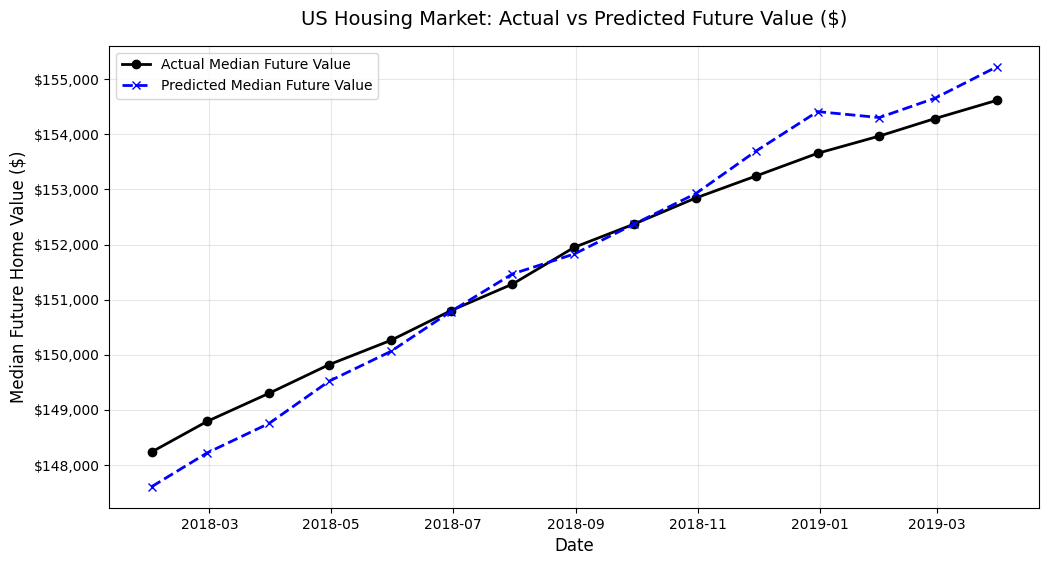

----------------------------------------
THE FINANCIAL COST OF YOUR MODEL'S ERROR
----------------------------------------
Median Base Home Value in Test Set: $144,695.00
Your model's MAE: ~2.8%
In real financial terms, your model's forecast is off by an average of: $6,264.14 per house.


In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get percentage predictions from your model
predictions_pct = final_model.predict(X_final_test_processed)
plot_df = df_final_test.copy()

# 2. CONVERT PERCENTAGES BACK TO DOLLARS
# Formula: Future Value = Current Value * (1 + (Appreciation_Percentage / 100))
plot_df['Actual_Future_Value_$'] = plot_df['HomeValue'] * (1 + (plot_df['Target_Appreciation_12M'] / 100))
plot_df['Predicted_Future_Value_$'] = plot_df['HomeValue'] * (1 + (predictions_pct / 100))

# Calculate the absolute dollar error for every single house forecast
plot_df['Dollar_Error'] = abs(plot_df['Actual_Future_Value_$'] - plot_df['Predicted_Future_Value_$'])

# 3. AGGREGATE: Get the Median dollar values across the US for each Date
macro_trend_dollars = plot_df.groupby('Date')[['Actual_Future_Value_$', 'Predicted_Future_Value_$']].median().reset_index()
macro_trend_dollars = macro_trend_dollars.sort_values('Date')

# 4. PLOTTING
plt.figure(figsize=(12, 6))

plt.plot(
    macro_trend_dollars['Date'], 
    macro_trend_dollars['Actual_Future_Value_$'], 
    label='Actual Median Future Value', 
    color='black', 
    marker='o', 
    linewidth=2
)

plt.plot(
    macro_trend_dollars['Date'], 
    macro_trend_dollars['Predicted_Future_Value_$'], 
    label='Predicted Median Future Value', 
    color='blue', 
    marker='x', 
    linestyle='--', 
    linewidth=2
)

plt.title('US Housing Market: Actual vs Predicted Future Value ($)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Median Future Home Value ($)', fontsize=12)

# Format the Y-axis to show clean dollar amounts (e.g., $350,000)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.0f}".format(x)))

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. THE BRUTAL REALITY OF YOUR ERROR METRIC
median_base_price = plot_df['HomeValue'].median()
average_dollar_error = plot_df['Dollar_Error'].mean()

print("-" * 40)
print("THE FINANCIAL COST OF YOUR MODEL'S ERROR")
print("-" * 40)
print(f"Median Base Home Value in Test Set: ${median_base_price:,.2f}")
print(f"Your model's MAE: ~2.8%")
print(f"In real financial terms, your model's forecast is off by an average of: ${average_dollar_error:,.2f} per house.")

In [60]:
# 1. Ensure predictions are generated and assigned to plot_df
# Re-running this ensures the column definitely exists
predictions = final_model.predict(X_final_test_processed)
plot_df = df_final_test.copy()
plot_df['Predicted_Appreciation_12M'] = predictions

# 2. Now perform the aggregation
macro_stats = plot_df.groupby('Date').agg(
    median_actual=('Target_Appreciation_12M', 'median'),
    median_predicted=('Predicted_Appreciation_12M', 'median'),
    sample_size=('RegionID', 'count')
).reset_index().sort_values('Date')

# 3. Check for success
print("Columns in plot_df:", plot_df.columns.tolist())
print("Macro stats head:")
print(macro_stats.head())

Columns in plot_df: ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'Metro', 'CountyName', 'Date', 'HomeValue', 'year', 'month', 'FutureDate_12M', 'Future_HomeValue_12M', 'Target_Appreciation_12M', 'HomeValue_Lag_1M', 'HomeValue_Lag_3M', 'HomeValue_Lag_6M', 'HomeValue_Lag_12M', 'Growth_3M_pct', 'Growth_6M_pct', 'Growth_12M_pct', 'RollingMean_3M', 'RollingStd_6M', 'Month_Sin', 'Month_Cos', 'Predicted_Appreciation_12M']
Macro stats head:
        Date  median_actual  median_predicted  sample_size
0 2018-01-31       4.719559          4.582745        26958
1 2018-02-28       4.604653          4.541797        26976
2 2018-03-31       4.482673          4.486902        27005
3 2018-04-30       4.392585          4.529305        27024
4 2018-05-31       4.302363          4.548378        27058


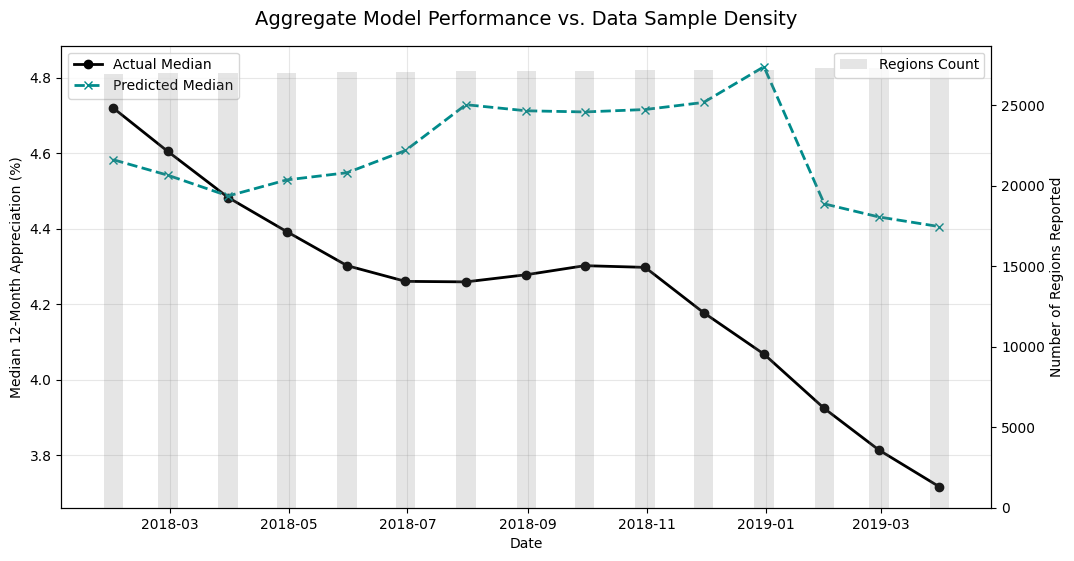

In [61]:
import matplotlib.pyplot as plt

# 1. Prepare data with count
# We group by Date to get median values AND the count of regions for that date
macro_stats = plot_df.groupby('Date').agg(
    median_actual=('Target_Appreciation_12M', 'median'),
    median_predicted=('Predicted_Appreciation_12M', 'median'),
    sample_size=('RegionID', 'count') # This is the count per date
).reset_index().sort_values('Date')

# 2. Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1: The Appreciation Lines
ax1.plot(macro_stats['Date'], macro_stats['median_actual'], label='Actual Median', color='black', marker='o', linewidth=2)
ax1.plot(macro_stats['Date'], macro_stats['median_predicted'], label='Predicted Median', color='darkcyan', marker='x', linestyle='--', linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel('Median 12-Month Appreciation (%)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Axis 2: The Sample Size (Bar Chart on secondary axis)
ax2 = ax1.twinx()
ax2.bar(macro_stats['Date'], macro_stats['sample_size'], color='gray', alpha=0.2, label='Regions Count', width=10)
ax2.set_ylabel('Number of Regions Reported')
ax2.legend(loc='upper right')

plt.title('Aggregate Model Performance vs. Data Sample Density', fontsize=14, pad=15)
plt.show()

In [ ]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

# Save the fitted categorical preprocessor
joblib.dump(
    final_preprocessor,
    "artifacts/preprocessor.joblib"
)

# Save the XGBoost model
final_model.save_model("artifacts/xgb_model.json")

print("Artifacts saved successfully.")

Artifacts saved successfully.


In [ ]:
# Choose 100 largest markets using the lowest SizeRank values
demo_region_ids = (
    df_final_test[["RegionID", "SizeRank"]]
    .drop_duplicates()
    .sort_values("SizeRank")
    .head(100)["RegionID"]
)

# Create one mask and reuse it everywhere
demo_mask = df_final_test["RegionID"].isin(demo_region_ids)

demo_data = df_final_test.loc[demo_mask].copy()

# Store prediction and actual values for transparent demonstration
demo_data["Predicted_Appreciation_12M"] = test_predictions[demo_mask.to_numpy()]
demo_data["Actual_Appreciation_12M"] = y_final_test.loc[demo_mask].to_numpy()

demo_columns = [
    "RegionID",
    "RegionName",
    "RegionType",
    "State",
    "Metro",
    "CountyName",
    "SizeRank",
    "Date",
    "HomeValue",
    "Target_Appreciation_12M",
    "Predicted_Appreciation_12M",
    "Actual_Appreciation_12M",
    *numeric_features,
    *categorical_features
]

# Remove duplicates while preserving order
demo_columns = list(dict.fromkeys(demo_columns))

demo_data = demo_data.loc[:, demo_columns]

demo_data.to_parquet(
    "artifacts/demo_test_data.parquet",
    index=False
)

print(demo_data.shape)
print(
    f"Saved file size: "
    f"{demo_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

(1500, 24)
Saved file size: 0.64 MB


In [ ]:
import os

save_path = "/content/drive/MyDrive/PROJECTS/Zillow/dataset"
os.makedirs(save_path, exist_ok=True)

df_model_features.to_feather(
    f"{save_path}/df_model_features.feather"
)

print("Saved:", df_model_features.shape)

Saved: (5248946, 26)


In [ ]:
print(os.path.exists(
    "/content/drive/MyDrive/PROJECTS/Zillow/dataset/df_model_features.feather"
))

True


In [ ]:
df_model_features = pd.read_feather(
    "/content/drive/MyDrive/PROJECTS/Zillow/dataset/df_model_features.feather"
)

print(df_model_features.shape)

In [43]:
numeric_features = [
    "HomeValue",
    "SizeRank",
    "year",
    "Month_Sin",
    "Month_Cos",
    "HomeValue_Lag_1M",
    "HomeValue_Lag_3M",
    "HomeValue_Lag_6M",
    "HomeValue_Lag_12M",
    "Growth_3M_pct",
    "Growth_6M_pct",
    "Growth_12M_pct",
    "RollingMean_3M",
    "RollingStd_6M"
]

categorical_features = [
    "RegionType",
    "State",
    "Metro",
    "CountyName"
]

target = "Target_Appreciation_12M"

train_mask = df_model_features["Date"] <= "2014-12-31"

val_mask = (
    (df_model_features["Date"] >= "2016-01-31")
    & (df_model_features["Date"] <= "2016-12-31")
)

df_train_features = df_model_features.loc[train_mask]
df_val_features = df_model_features.loc[val_mask]

print("Train:", df_train_features.shape)
print("Validation:", df_val_features.shape)

Train: (3896655, 26)
Validation: (316000, 26)


In [44]:
feature_cols = numeric_features + categorical_features

df_rf_train = df_train_features.sample(
    n=min(400_000, len(df_train_features)),
    random_state=42
)

X_rf_train = df_rf_train[feature_cols]
y_rf_train = df_rf_train[target]

X_rf_val = df_val_features[feature_cols]
y_rf_val = df_val_features[target]

print("RF train:", X_rf_train.shape)
print("RF validation:", X_rf_val.shape)

RF train: (400000, 18)
RF validation: (316000, 18)


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_features
        ),
        ("num", "passthrough", numeric_features)
    ],
    remainder="drop"
)

X_rf_train_processed = rf_preprocessor.fit_transform(
    X_rf_train
).astype("float32")

X_rf_val_processed = rf_preprocessor.transform(
    X_rf_val
).astype("float32")

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=5,
    max_features=0.7,
    max_samples=0.7,
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_model.fit(X_rf_train_processed, y_rf_train)

rf_val_pred = rf_model.predict(X_rf_val_processed)

rf_mae = mean_absolute_error(y_rf_val, rf_val_pred)
rf_rmse = mean_squared_error(y_rf_val, rf_val_pred) ** 0.5
rf_r2 = r2_score(y_rf_val, rf_val_pred)

print(f"Random Forest MAE:  {rf_mae:.3f}")
print(f"Random Forest RMSE: {rf_rmse:.3f}")
print(f"Random Forest R²:   {rf_r2:.3f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   45.8s
[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed:  3.2min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s


Random Forest MAE:  3.007
Random Forest RMSE: 4.093
Random Forest R²:   0.072


[Parallel(n_jobs=8)]: Done 150 out of 150 | elapsed:    1.6s finished


In [47]:
comparison_results = pd.DataFrame({
    "Model": [
        "Dummy Mean Baseline",
        "Naive Momentum Baseline",
        "SGDRegressor",
        "Random Forest (400k sample)",
        "Tuned XGBoost"
    ],
    "MAE": [
        dummy_mae,
        naive_mae,
        sgd_mae,
        rf_mae,
        final_val_mae
    ],
    "RMSE": [
        dummy_rmse,
        naive_rmse,
        sgd_rmse,
        rf_rmse,
        final_val_rmse
    ],
    "R2": [
        dummy_r2,
        naive_r2,
        sgd_r2,
        rf_r2,
        final_val_r2
    ]
}).sort_values("MAE")

display(comparison_results)

,Model,MAE,RMSE,R2
4,Tuned XGBoost,2.978275,4.048130,0.091744
3,Random Forest (400k sample),3.007438,4.092811,0.071584
0,Dummy Mean Baseline,3.717128,4.855056,-0.306435
1,Naive Momentum Baseline,3.718618,5.316415,-0.566523
2,SGDRegressor,4.021255,5.151549,-0.470872


XGBoost was selected because it achieved the strongest validation performance across MAE, RMSE, and R². Random Forest was competitive but slightly weaker and required substantial computation even on a sampled training set. SGDRegressor performed poorly, indicating that linear relationships were insufficient for this forecasting task.